<a href="https://colab.research.google.com/github/yedam823/AI_study/blob/main/reinforcement_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
from collections import deque

# 1. 월드 모델 정의 (환경 규칙 커스텀)
class CartPole45DegWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        # 45도는 라디안으로 약 0.785. 상태를 [카트위치, 카트속도, 막대각도, 막대각속도]로 강제 덮어쓰기
        self.unwrapped.state = np.array([0.0, 0.0, math.pi / 4, 0.0], dtype=np.float32)
        return np.array(self.unwrapped.state, dtype=np.float32), info

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        x, x_dot, theta, theta_dot = state

        # 기존 12도 종료 조건을 해제하고 90도(수평)가 되면 종료하도록 수정
        terminated = bool(x < -2.4 or x > 2.4 or theta < -math.pi/2 or theta > math.pi/2)

        # 새로운 보상 함수: 수직(0도)에 가까울수록 큰 보상, 중앙에서 멀어지면 페널티
        reward = math.cos(theta) - (0.1 * abs(x))

        return state, reward, terminated, truncated, info

# 2. 신경망 뼈대 (작성해주신 구조 그대로 사용)
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(x)

# 3. 하이퍼파라미터 및 학습 준비
learning_rate = 0.001
gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 2000

# 커스텀 환경 생성
env = CartPole45DegWrapper(gym.make('CartPole-v1'))
model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict()) # 타겟 신경망 동기화
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
memory = deque(maxlen=10000)

print("🧠 45도 균형잡기 AI 학습 시작!")

# 4. 학습 루프
for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    while True:
        # Epsilon-Greedy 행동 선택
        if random.random() <= epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action = model(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 경험 저장
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward

        # 미니배치 학습
        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(np.array(states))
            actions = torch.LongTensor(actions).unsqueeze(1)
            rewards = torch.FloatTensor(rewards).unsqueeze(1)
            next_states = torch.FloatTensor(np.array(next_states))
            dones = torch.FloatTensor(dones).unsqueeze(1)

            # 현재 Q값과 타겟 Q값 계산
            q_values = model(states).gather(1, actions)
            next_q_values = target_model(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (gamma * next_q_values * (1 - dones))

            # 손실 계산 및 가중치 업데이트
            loss = criterion(q_values, target_q_values.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    # Epsilon 감소 및 타겟 신경망 업데이트
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    if episode % 100 == 0:
        print(f"Episode {episode} | Epsilon: {epsilon:.2f} | Total Reward: {total_reward:.2f}")

# 5. 새롭게 똑똑해진 뇌 저장
torch.save(model.state_dict(), 'cartpole_45deg_dqn.pth')
env.close()
print("🎉 학습 완료! 'cartpole_45deg_dqn.pth' 파일이 저장되었습니다.")

🧠 45도 균형잡기 AI 학습 시작!
Episode 0 | Epsilon: 0.99 | Total Reward: 9.02
Episode 100 | Epsilon: 0.60 | Total Reward: 11.63
Episode 200 | Epsilon: 0.37 | Total Reward: 12.26
Episode 300 | Epsilon: 0.22 | Total Reward: 14.75
Episode 400 | Epsilon: 0.13 | Total Reward: 15.29
Episode 500 | Epsilon: 0.08 | Total Reward: 19.78
Episode 600 | Epsilon: 0.05 | Total Reward: 14.65
Episode 700 | Epsilon: 0.03 | Total Reward: 19.84
Episode 800 | Epsilon: 0.02 | Total Reward: 19.82
Episode 900 | Epsilon: 0.01 | Total Reward: 17.53
Episode 1000 | Epsilon: 0.01 | Total Reward: 19.82
Episode 1100 | Epsilon: 0.01 | Total Reward: 19.81
Episode 1200 | Epsilon: 0.01 | Total Reward: 15.82
Episode 1300 | Epsilon: 0.01 | Total Reward: 19.82
Episode 1400 | Epsilon: 0.01 | Total Reward: 19.81
Episode 1500 | Epsilon: 0.01 | Total Reward: 19.82
Episode 1600 | Epsilon: 0.01 | Total Reward: 19.81
Episode 1700 | Epsilon: 0.01 | Total Reward: 19.84
Episode 1800 | Epsilon: 0.01 | Total Reward: 19.81
Episode 1900 | Epsilon:

In [ ]:
pip install matplotlib gymnasium torch numpy

🧠 500회 강화학습 시작!
Episode 50/500 | Epsilon: 0.61 | Avg Reward (last 50): 9.93
Episode 100/500 | Epsilon: 0.37 | Avg Reward (last 50): 12.27
Episode 150/500 | Epsilon: 0.22 | Avg Reward (last 50): 13.87
Episode 200/500 | Epsilon: 0.13 | Avg Reward (last 50): 15.28
Episode 250/500 | Epsilon: 0.08 | Avg Reward (last 50): 16.50
Episode 300/500 | Epsilon: 0.05 | Avg Reward (last 50): 18.22
Episode 350/500 | Epsilon: 0.03 | Avg Reward (last 50): 18.26
Episode 400/500 | Epsilon: 0.02 | Avg Reward (last 50): 18.37
Episode 450/500 | Epsilon: 0.01 | Avg Reward (last 50): 19.15
Episode 500/500 | Epsilon: 0.01 | Avg Reward (last 50): 19.49

🎉 학습 완료! 'cartpole_45deg_500ep.pth' 파일이 저장되었습니다.
📈 학습 진행 결과 그래프를 생성합니다...


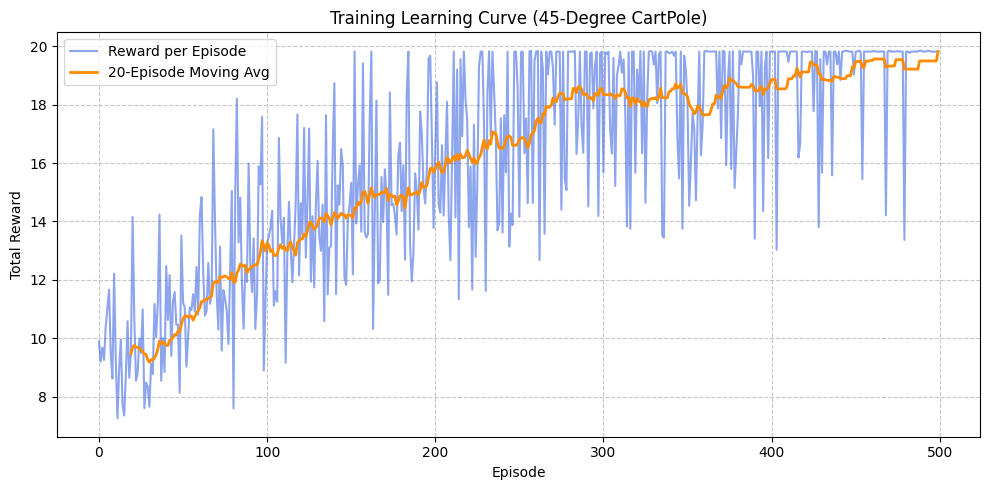

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
from collections import deque
import matplotlib.pyplot as plt

# ==========================================
# 1. 월드 모델 정의 (45도 시작, 보상 커스텀)
# ==========================================
class CartPole45DegWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        # 45도(pi/4)에서 시작
        self.unwrapped.state = np.array([0.0, 0.0, math.pi / 4, 0.0], dtype=np.float32)
        return np.array(self.unwrapped.state, dtype=np.float32), info

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        x, x_dot, theta, theta_dot = state

        # 각도 제한을 90도(수평)로 완화, 화면 밖으로 나가면 종료
        terminated = bool(x < -2.4 or x > 2.4 or theta < -math.pi/2 or theta > math.pi/2)

        # 보상 함수: 수직(0도)에 가까울수록 +보상, 중앙에서 멀어지면 -페널티
        reward = math.cos(theta) - (0.1 * abs(x))

        return state, reward, terminated, truncated, info

# ==========================================
# 2. 신경망 뼈대 (DQN)
# ==========================================
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(x)

# ==========================================
# 3. 학습 하이퍼파라미터 설정
# ==========================================
EPISODES = 500 # 사용자가 요청한 500번의 학습 테스트
learning_rate = 0.001
gamma = 0.99
batch_size = 64
epsilon = 1.0          # 100% 랜덤 행동으로 시작
epsilon_decay = 0.99   # 500번 안에 수렴하도록 감소율 조정 (기존 0.995 -> 0.99)
epsilon_min = 0.01

# 환경 및 모델 초기화
env = CartPole45DegWrapper(gym.make('CartPole-v1'))
model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
memory = deque(maxlen=10000)

# 학습 과정 기록용 리스트
scores_history = []

print(f"🧠 {EPISODES}회 강화학습 시작!")

# ==========================================
# 4. 500회 강화학습 루프
# ==========================================
for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0
    steps = 0

    while True:
        # Epsilon-Greedy 탐색
        if random.random() <= epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action = model(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)

        # 500 스텝 이상 버티면 강제 종료 (성공으로 간주)
        if steps > 500:
            truncated = True

        done = terminated or truncated

        # 기억 저장
        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        steps += 1

        # 미니배치 학습 (경험이 충분히 쌓인 후부터)
        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(np.array(states))
            actions = torch.LongTensor(actions).unsqueeze(1)
            rewards = torch.FloatTensor(rewards).unsqueeze(1)
            next_states = torch.FloatTensor(np.array(next_states))
            dones = torch.FloatTensor(dones).unsqueeze(1)

            q_values = model(states).gather(1, actions)
            next_q_values = target_model(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (gamma * next_q_values * (1 - dones))

            loss = criterion(q_values, target_q_values.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    # Epsilon 업데이트 및 타겟 모델 동기화
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    # 결과 기록
    scores_history.append(total_reward)

    # 50번마다 로그 출력
    if (episode + 1) % 50 == 0:
        avg_score = np.mean(scores_history[-50:]) # 최근 50번의 평균 점수
        print(f"Episode {episode + 1}/{EPISODES} | Epsilon: {epsilon:.2f} | Avg Reward (last 50): {avg_score:.2f}")

# 모델 저장
torch.save(model.state_dict(), 'cartpole_45deg_500ep.pth')
env.close()
print("\n🎉 학습 완료! 'cartpole_45deg_500ep.pth' 파일이 저장되었습니다.")

# ==========================================
# 5. 학습 곡선 (Learning Curve) 그래프 그리기
# ==========================================
print("📈 학습 진행 결과 그래프를 생성합니다...")

plt.figure(figsize=(10, 5))
plt.plot(scores_history, color='royalblue', alpha=0.6, label='Reward per Episode')

# 추세선 (이동 평균선, Moving Average) 추가 - 20 에피소드 기준
moving_avg = np.convolve(scores_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, EPISODES), moving_avg, color='darkorange', linewidth=2, label='20-Episode Moving Avg')

plt.title('Training Learning Curve (45-Degree CartPole)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

🧠 목표 10초(500스텝) 달성을 위한 2000회 심화 학습 시작!
Episode 100/2000 | Epsilon: 0.82 | Avg Steps (last 100): 21.0 / 500
Episode 200/2000 | Epsilon: 0.67 | Avg Steps (last 100): 22.1 / 500
Episode 300/2000 | Epsilon: 0.55 | Avg Steps (last 100): 23.8 / 500
Episode 400/2000 | Epsilon: 0.45 | Avg Steps (last 100): 24.8 / 500
Episode 500/2000 | Epsilon: 0.37 | Avg Steps (last 100): 26.1 / 500
Episode 600/2000 | Epsilon: 0.30 | Avg Steps (last 100): 27.7 / 500
Episode 700/2000 | Epsilon: 0.25 | Avg Steps (last 100): 29.5 / 500
Episode 800/2000 | Epsilon: 0.20 | Avg Steps (last 100): 31.1 / 500
Episode 900/2000 | Epsilon: 0.17 | Avg Steps (last 100): 31.9 / 500
Episode 1000/2000 | Epsilon: 0.14 | Avg Steps (last 100): 34.6 / 500
Episode 1100/2000 | Epsilon: 0.11 | Avg Steps (last 100): 35.0 / 500
Episode 1200/2000 | Epsilon: 0.09 | Avg Steps (last 100): 37.4 / 500
Episode 1300/2000 | Epsilon: 0.07 | Avg Steps (last 100): 37.1 / 500
Episode 1400/2000 | Epsilon: 0.06 | Avg Steps (last 100): 38.6 / 500
Epis

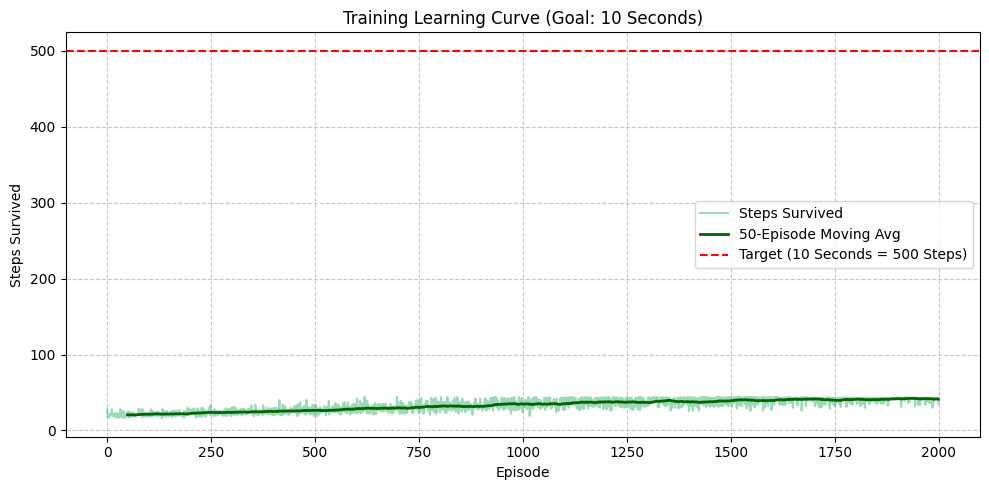

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
from collections import deque
import matplotlib.pyplot as plt

# ==========================================
# 1. 월드 모델: 무한 맵 & 45도 시작 커스텀
# ==========================================
class CartPole10SecWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        # 45도(pi/4)에서 시작
        self.unwrapped.state = np.array([0.0, 0.0, math.pi / 4, 0.0], dtype=np.float32)
        return np.array(self.unwrapped.state, dtype=np.float32), info

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        x, x_dot, theta, theta_dot = state

        # 💡 핵심 변경점: 카트가 이동할 수 있는 트랙 한계를 2.4에서 10.0으로 대폭 확장!
        terminated = bool(x < -10.0 or x > 10.0 or theta < -math.pi/2 or theta > math.pi/2)

        # 보상: 막대 세우기를 최우선으로 하되, 너무 멀리 가지 않도록 약한 페널티 부여
        reward = math.cos(theta) - (0.02 * abs(x))

        return state, reward, terminated, truncated, info

# ==========================================
# 2. 신경망 뼈대 (DQN)
# ==========================================
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(x)

# ==========================================
# 3. 심화 학습 하이퍼파라미터
# ==========================================
EPISODES = 2000        # 학습 횟수 대폭 증가 (충분한 경험 제공)
TARGET_STEPS = 500     # 목표 버티기 스텝 (0.02초 * 500 = 10초)
learning_rate = 0.001
gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_decay = 0.998  # 2000번에 걸쳐 천천히 탐험하도록 감소율 조절
epsilon_min = 0.01

env = CartPole10SecWrapper(gym.make('CartPole-v1'))
model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
memory = deque(maxlen=20000) # 기억 용량도 증가

scores_history = []

print(f"🧠 목표 10초({TARGET_STEPS}스텝) 달성을 위한 {EPISODES}회 심화 학습 시작!")

# ==========================================
# 4. 학습 루프
# ==========================================
for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0
    steps = 0

    while True:
        if random.random() <= epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action = model(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)

        # 💡 목표 시간(10초)을 버티면 해당 에피소드 조기 종료 (성공!)
        if steps >= TARGET_STEPS:
            truncated = True

        done = terminated or truncated

        memory.append((state, action, reward, next_state, done))
        state = next_state
        total_reward += reward
        steps += 1

        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(np.array(states))
            actions = torch.LongTensor(actions).unsqueeze(1)
            rewards = torch.FloatTensor(rewards).unsqueeze(1)
            next_states = torch.FloatTensor(np.array(next_states))
            dones = torch.FloatTensor(dones).unsqueeze(1)

            q_values = model(states).gather(1, actions)
            next_q_values = target_model(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (gamma * next_q_values * (1 - dones))

            loss = criterion(q_values, target_q_values.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    scores_history.append(steps) # 이번엔 보기 쉽게 '버틴 스텝 수'를 기록

    if (episode + 1) % 100 == 0:
        avg_steps = np.mean(scores_history[-100:])
        print(f"Episode {episode + 1}/{EPISODES} | Epsilon: {epsilon:.2f} | Avg Steps (last 100): {avg_steps:.1f} / {TARGET_STEPS}")

# 새로운 뇌 파일 저장
torch.save(model.state_dict(), 'cartpole_45deg_10sec.pth')
env.close()
print("\n🎉 심화 학습 완료! 'cartpole_45deg_10sec.pth' 파일이 저장되었습니다.")

# ==========================================
# 5. 스텝(버틴 시간) 기준 그래프 그리기
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(scores_history, color='mediumseagreen', alpha=0.5, label='Steps Survived')
moving_avg = np.convolve(scores_history, np.ones(50)/50, mode='valid')
plt.plot(range(49, EPISODES), moving_avg, color='darkgreen', linewidth=2, label='50-Episode Moving Avg')

plt.axhline(y=TARGET_STEPS, color='red', linestyle='--', label='Target (10 Seconds = 500 Steps)')

plt.title('Training Learning Curve (Goal: 10 Seconds)')
plt.xlabel('Episode')
plt.ylabel('Steps Survived')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

🏎️ 스포츠카 엔진 장착 완료! 10초 버티기 1000회 학습 시작!
Episode 50/1000 | Epsilon: 0.78 | Avg Steps: 29.1 / 500
Episode 100/1000 | Epsilon: 0.61 | Avg Steps: 45.4 / 500
Episode 150/1000 | Epsilon: 0.47 | Avg Steps: 61.7 / 500
Episode 200/1000 | Epsilon: 0.37 | Avg Steps: 77.8 / 500
Episode 250/1000 | Epsilon: 0.29 | Avg Steps: 134.0 / 500
Episode 300/1000 | Epsilon: 0.22 | Avg Steps: 142.4 / 500
Episode 350/1000 | Epsilon: 0.17 | Avg Steps: 372.2 / 500
Episode 400/1000 | Epsilon: 0.13 | Avg Steps: 204.6 / 500
Episode 450/1000 | Epsilon: 0.10 | Avg Steps: 270.9 / 500
Episode 500/1000 | Epsilon: 0.08 | Avg Steps: 453.1 / 500
Episode 550/1000 | Epsilon: 0.06 | Avg Steps: 365.3 / 500
Episode 600/1000 | Epsilon: 0.05 | Avg Steps: 478.0 / 500
Episode 650/1000 | Epsilon: 0.04 | Avg Steps: 481.9 / 500
Episode 700/1000 | Epsilon: 0.03 | Avg Steps: 471.5 / 500
Episode 750/1000 | Epsilon: 0.02 | Avg Steps: 475.2 / 500
Episode 800/1000 | Epsilon: 0.02 | Avg Steps: 493.7 / 500
Episode 850/1000 | Epsilon: 0.01 | Avg

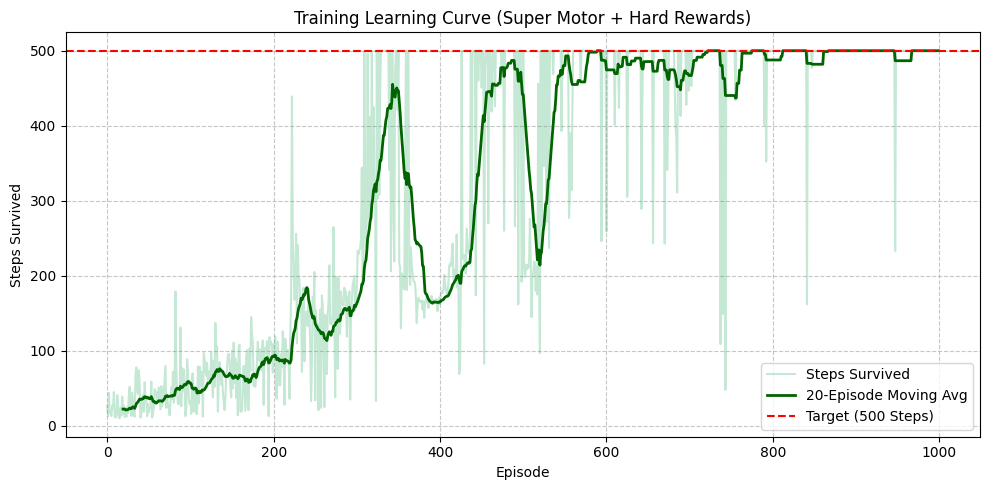

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import math
from collections import deque
import matplotlib.pyplot as plt

# ==========================================
# 1. 월드 모델: 튜닝된 카트 (슈퍼 모터 장착 + 강력한 보상)
# ==========================================
class CartPoleTunedWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def reset(self, **kwargs):
        state, info = self.env.reset(**kwargs)
        # 💡 물리 엔진 해킹: 카트의 미는 힘을 10.0 -> 50.0으로 5배 강화!
        self.unwrapped.force_mag = 50.0

        # 45도(pi/4)에서 시작
        self.unwrapped.state = np.array([0.0, 0.0, math.pi / 4, 0.0], dtype=np.float32)
        return np.array(self.unwrapped.state, dtype=np.float32), info

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        x, x_dot, theta, theta_dot = state

        out_of_bounds = bool(x < -10.0 or x > 10.0)
        fallen = bool(theta < -math.pi/2 or theta > math.pi/2)
        terminated = out_of_bounds or fallen

        # 💡 채찍과 당근 보상 체계
        if terminated:
            reward = -100.0 # 죽으면 엄청난 페널티 (채찍)
        else:
            # 수직(0도)에 가까울수록, 중앙(x=0)에 있을수록 높은 점수 (당근)
            angle_reward = 1.0 - (abs(theta) / (math.pi/2))
            pos_reward = 1.0 - (abs(x) / 10.0)
            reward = (angle_reward * 2.0) + pos_reward

        return state, reward, terminated, truncated, info

# ==========================================
# 2. 신경망 뼈대 (DQN)
# ==========================================
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128), # 두뇌 용량을 조금 늘림 (64 -> 128)
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.fc(x)

# ==========================================
# 3. 학습 설정
# ==========================================
EPISODES = 1000        # 모터가 좋아져서 1000번이면 충분합니다.
TARGET_STEPS = 500     # 10초(500스텝) 목표
learning_rate = 0.0005 # 더 안정적인 학습을 위해 보폭 감소
gamma = 0.99
batch_size = 64
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

env = CartPoleTunedWrapper(gym.make('CartPole-v1'))
model = DQN()
target_model = DQN()
target_model.load_state_dict(model.state_dict())
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
memory = deque(maxlen=20000)

scores_history = []

print(f"🏎️ 스포츠카 엔진 장착 완료! 10초 버티기 {EPISODES}회 학습 시작!")

# ==========================================
# 4. 학습 루프
# ==========================================
for episode in range(EPISODES):
    state, _ = env.reset()
    steps = 0

    while True:
        if random.random() <= epsilon:
            action = env.action_space.sample()
        else:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action = model(state_tensor).argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)

        if steps >= TARGET_STEPS:
            truncated = True

        done = terminated or truncated

        memory.append((state, action, reward, next_state, done))
        state = next_state
        steps += 1

        if len(memory) > batch_size:
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            states = torch.FloatTensor(np.array(states))
            actions = torch.LongTensor(actions).unsqueeze(1)
            rewards = torch.FloatTensor(rewards).unsqueeze(1)
            next_states = torch.FloatTensor(np.array(next_states))
            dones = torch.FloatTensor(dones).unsqueeze(1)

            q_values = model(states).gather(1, actions)
            next_q_values = target_model(next_states).max(1)[0].unsqueeze(1)
            target_q_values = rewards + (gamma * next_q_values * (1 - dones))

            loss = criterion(q_values, target_q_values.detach())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    scores_history.append(steps)

    if (episode + 1) % 50 == 0:
        avg_steps = np.mean(scores_history[-50:])
        print(f"Episode {episode + 1}/{EPISODES} | Epsilon: {epsilon:.2f} | Avg Steps: {avg_steps:.1f} / {TARGET_STEPS}")

torch.save(model.state_dict(), 'cartpole_45deg_super.pth')
env.close()
print("\n🎉 스포츠카 튜닝 학습 완료! 'cartpole_45deg_super.pth' 저장됨.")

# ==========================================
# 5. 결과 그래프
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(scores_history, color='mediumseagreen', alpha=0.3, label='Steps Survived')
moving_avg = np.convolve(scores_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, EPISODES), moving_avg, color='darkgreen', linewidth=2, label='20-Episode Moving Avg')

plt.axhline(y=TARGET_STEPS, color='red', linestyle='--', label='Target (500 Steps)')
plt.title('Training Learning Curve (Super Motor + Hard Rewards)')
plt.xlabel('Episode')
plt.ylabel('Steps Survived')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()